# Event Selection

**_must run with dfs with all reconstructed slices and tracks_**

This notebook runs the full event selection, evaluating selection performance:

- mode breakdown bar plots for each selection stage
- purity/efficiency summary plots

## Recommended: batched workflow (full sample)

When input `.df` files are too large to load at once, set **`USE_BATCHED_WORKFLOW = True`** in the next section. That surveys file sizes, groups inputs into **≤1 GiB jobs**, runs the notebook selection pipeline per job, saves histogram/count pickles (with per-file POT metadata), then aggregates and plots.

Shell equivalent: `analysis_village/numucc_1p0pi/scripts/run_event_selection_batched.sh`.

## Legacy: in-memory workflow

Set **`USE_BATCHED_WORKFLOW = False`** only for small test samples. The cells below load concatenated dataframes into RAM and step through cuts interactively.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# print avaialbe memory
import psutil

vmem = psutil.virtual_memory()
print(f"Available memory: {vmem.available / 1024 ** 3:.2f} GiB / {vmem.total / 1024 ** 3:.2f} GiB total")
print(f"Used: {vmem.used / 1024 ** 3:.2f} GiB ({vmem.percent}%)")

Available memory: 108.18 GiB / 125.14 GiB total
Used: 16.96 GiB (13.6%)


In [3]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime
import pickle

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
# turn off RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Configs

In [5]:
# ===== files =====
base_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"

# mc_dir = "2026_09_04_172912__sel_all-mc-CV_updated"
mc_dir = "2026_09_04_172912__sel_all-mc-CV"
mc_dirt_dir = "2026_09_01_135047__sel_all-mc-dirt_updated"
mc_intime_dir = "2026_09_01_135508__sel_all-mc-Intime_updated"
data_dir = "2026_09_04_172930__sel_all-data-1e20"
# data_dir = "2026_09_04_172930__sel_all-data-1e20_updated"
data_offbeam_dir = "2026_09_01_140024__sel_all-data-OffBeamLight_updated"

import glob
# print how many *df files are in each directory
for this_dir in [mc_dir, mc_dirt_dir, mc_intime_dir, data_dir, data_offbeam_dir]:
    print(f"{this_dir}: {len(glob.glob(f'{base_dir}/{this_dir}/*.df'))}")

2026_09_04_172912__sel_all-mc-CV: 2000
2026_09_01_135047__sel_all-mc-dirt_updated: 500
2026_09_01_135508__sel_all-mc-Intime_updated: 500
2026_09_04_172930__sel_all-data-1e20: 500
2026_09_01_140024__sel_all-data-OffBeamLight_updated: 500


In [14]:
# ===== plot configs =====
from analysis_village.numucc_1p0pi.dataset_locations import PLOTS_BASE

today_str = datetime.now().strftime("%Y%m%d")
today_str = "PRL"
syst_tag = ""

# Optional overrides (None → dated work dir under /exp/sbnd/data/users/$USER/...)
plots_dir = path.join(PLOTS_BASE, f"event_selection-{syst_tag}-{today_str}")

## Batched workflow (recommended for full samples)

Surveys `EVENT_SELECTION_GLOBS`, packs files into ≤1 GiB jobs, runs the notebook pipeline per job, then aggregates histograms and renders plots.

Edit paths in `analysis_village/numucc_1p0pi/dataset_locations.py` (`EVENT_SELECTION_GLOBS`) if needed.

In [ ]:
batch_work_base = None
batch_plots_dir = plots_dir

In [7]:
USE_BATCHED_WORKFLOW = False  # False → legacy in-memory cells below (small tests only)

from analysis_village.numucc_1p0pi.event_selection_batched import (
    EventSelectionBatchedConfig,
    discover_jobs,
    run_full,
    show_saved_plots,
    default_event_selection_batched_work_root,
)

batch_cfg = EventSelectionBatchedConfig(
    work_base=batch_work_base or default_event_selection_batched_work_root(today_str),
    plots_dir=batch_plots_dir,
    max_job_bytes=int(1.0 * 1024**3),  # 1 GiB per job
    mc_univ_syst=("Flux", "G4", "GENIE"),
    skip_existing_batches=True,
    aggregate_only=False,
    skip_aggregate=False,
    save_fig=True,
    show_fig=False,
    # max_files_per_sample=1,  # smoke test: one file per sample
)

if USE_BATCHED_WORKFLOW:
    records, jobs, manifest_path = discover_jobs(batch_cfg)
    print(f"Batched workflow: {len(jobs)} job(s)  manifest={manifest_path}")
    for j in jobs[:8]:
        print(f"  {j.sample} {j.tag}: {len(j.files)} file(s), {j.total_bytes / (1024**3):.3f} GiB")
    if len(jobs) > 8:
        print(f"  ... and {len(jobs) - 8} more")

In [8]:
batch_result = None

if USE_BATCHED_WORKFLOW:
    batch_result = run_full(batch_cfg)

    save_fig_dir = str(batch_result.plots_dir)
    save_fig = batch_cfg.save_fig
    show_plot = batch_cfg.show_fig
    pot_str = batch_result.pot_str
    data_tot_pot = batch_result.data_pot
    merged_payload = batch_result.merged_payload

    print("Batched workflow complete.")
    print("  batches:", batch_result.batches_dir)
    print("  plots  :", batch_result.plots_dir)
    print("  manifest:", batch_result.manifest_path)
    print("  POT    :", pot_str)

    # Uncomment to preview PNGs inline (can be slow for many plots):
    # show_saved_plots(batch_result.plots_dir, max_images=20)
else:
    print("USE_BATCHED_WORKFLOW=False — run legacy data-loading cells below.")

USE_BATCHED_WORKFLOW=False — run legacy data-loading cells below.


# Legacy in-memory event selection

**Skip this section when `USE_BATCHED_WORKFLOW=True`** — plots and `merged_histdata.pkl` are already written by the batched workflow above.

In [31]:
if not USE_BATCHED_WORKFLOW:
    from pyanalib.split_df_helpers_new import *

    n_max_files = 10

    # MC
    df_dir = os.path.join(base_dir, mc_dir)
    keys2load_mc = ['hdr', 'evt', 'trk']
    mc_dfs = dfs_from_dir(
        search_dir=df_dir,
        filename_str="sel_all",
        keys2load=keys2load_mc,
        n_max_concat=n_max_files,
    )

    # BNB on-beam data
    df_dir = os.path.join(base_dir, data_dir)
    keys2load_data = ['evt', 'trk', 'hdr', 'bnbpot']
    data_dfs = dfs_from_dir(
        search_dir=df_dir,
        filename_str="sel_all",
        keys2load=keys2load_data,
        n_max_concat=n_max_files,
    )

    # Intime
    df_dir = os.path.join(base_dir, mc_intime_dir)
    keys2load_intime = ['hdr', 'evt', 'trk']
    intime_dfs = dfs_from_dir(
        search_dir=df_dir,
        filename_str="sel_all",
        keys2load=keys2load_intime,
        n_max_concat=n_max_files,
    )

    # Offbeam
    df_dir = os.path.join(base_dir, data_offbeam_dir)
    keys2load_offbeam = ['hdr', 'evt', 'trk']
    offbeam_dfs = dfs_from_dir(
        search_dir=df_dir,
        filename_str="sel_all",
        keys2load=keys2load_offbeam,
        n_max_concat=n_max_files,
    )

    # Dirt
    df_dir = os.path.join(base_dir, mc_dirt_dir)
    keys2load_dirt = ['hdr', 'evt', 'trk']
    dirt_dfs = dfs_from_dir(
        search_dir=df_dir,
        filename_str="sel_all",
        keys2load=keys2load_dirt,
        n_max_concat=n_max_files,
    )
else:
    print("Skipping legacy dfs_from_dir load — batched workflow already produced plots.")

Found 10 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_1002.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_1003.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172912__sel_all-mc-CV/sel_all-mc-CV_10

100%|██████████| 10/10 [00:05<00:00,  1.85it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 10 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172930__sel_all-data-1e20/sel_all-data-1e20_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172930__sel_all-data-1e20/sel_all-data-1e20_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172930__sel_all-data-1e20/sel_all-data-1e20_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172930__sel_all-data-1e20/sel_all-data-1e20_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172930__sel_all-data-1e20/sel_all-data-1e20_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172930__sel_all-data-1e20/sel_all-data-1e20_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172930__sel_all-data-1e20/sel_all-data-1e20_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_04_172930__sel_all-data-1e20/sel_all-data-1e20_104.df

100%|██████████| 10/10 [00:13<00:00,  1.34s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 10 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135508__sel_all-mc-Intime_updated/sel_all-mc-Intime_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135508__sel_all-mc-Intime_updated/sel_all-mc-Intime_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135508__sel_all-mc-Intime_updated/sel_all-mc-Intime_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135508__sel_all-mc-Intime_updated/sel_all-mc-Intime_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135508__sel_all-mc-Intime_updated/sel_all-mc-Intime_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135508__sel_all-mc-Intime_updated/sel_all-mc-Intime_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135508__sel_all-mc-Intime_updated/sel_all-mc-Intime_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_

...

REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 10 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_140024__sel_all-data-OffBeamLight_updated/sel_all-data-OffBeamLight_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_140024__sel_all-data-OffBeamLight_updated/sel_all-data-OffBeamLight_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_140024__sel_all-data-OffBeamLight_updated/sel_all-data-OffBeamLight_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_140024__sel_all-data-OffBeamLight_updated/sel_all-data-OffBeamLight_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_140024__sel_all-data-OffBeamLight_updated/sel_all-data-OffBeamLight_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_140024__sel_all-data-OffBeamLight_updated/sel_all-data-OffBeamLight_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_140024__sel_all-data-

100%|██████████| 10/10 [00:07<00:00,  1.35it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 10 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135047__sel_all-mc-dirt_updated/sel_all-mc-dirt_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135047__sel_all-mc-dirt_updated/sel_all-mc-dirt_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135047__sel_all-mc-dirt_updated/sel_all-mc-dirt_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135047__sel_all-mc-dirt_updated/sel_all-mc-dirt_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135047__sel_all-mc-dirt_updated/sel_all-mc-dirt_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135047__sel_all-mc-dirt_updated/sel_all-mc-dirt_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135047__sel_all-mc-dirt_updated/sel_all-mc-dirt_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_135047__sel_all-mc-dir

100%|██████████| 10/10 [00:08<00:00,  1.16it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!


In [32]:
pot_str = "dummy"
plot_labels_bar = ["Events (POT={})".format(pot_str), "", ""]
plot_labels_hist = ["", "Events (POT={})".format(pot_str), ""]

In [33]:
if not USE_BATCHED_WORKFLOW:
    syst_tag = ""
    save_fig = True
    save_nevts = True
    show_plot = True

    save_fig_dir = plots_dir

    if save_fig:
        if not path.exists(save_fig_dir):
            makedirs(save_fig_dir)
        print("saving plots in ", save_fig_dir)

    save_nevts_dir = plots_dir
    if save_nevts:
        if not path.exists(save_nevts_dir):
            makedirs(save_nevts_dir)
        print("saving nevts in ", save_nevts_dir)
else:
    save_nevts = False
    print("Using batched plot output:", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/event_selection--PRL
saving nevts in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/event_selection--PRL


In [34]:
# for event selection summary plot
breakdown_dict = {"topology": {}, "genie": {}}

# save dfs per stage, df_dict used for efficiency plot
df_dict_mc = {} 
df_dict_data = {}
df_dict_intime = {} 
df_dict_offbeam = {}
df_dict_dirt = {}

In [35]:
def plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=True):

    ret_dict = {}

    for bar_type in ["topology", "genie"]: # "nu_cosmics"
        save_name = save_fig_dir + "/bar_plot-{}-{}.png".format(bar_type, stage_key)
        this_ret = bar_plot(breakdown_type=bar_type,
                            mc_df=mc_df, intime_df=intime_df, dirt_df=dirt_df,
                            show_plot=show_plot, plot_labels=plot_labels_bar,
                            save_fig=save_fig, save_name=save_name)
        ret_dict[bar_type] = this_ret

    return ret_dict

In [36]:
# save copies of original df
mc_dfs_     = mc_dfs
intime_dfs_ = intime_dfs
dirt_dfs_   = dirt_dfs

data_dfs_   = data_dfs
offbeam_dfs_ = offbeam_dfs


In [59]:
# -- Assign event and track DataFrames for each sample
mc_hdr_df, mc_evt_df, mc_trk_df = mc_dfs["hdr"], mc_dfs["evt"], mc_dfs["trk"]
data_hdr_df, data_evt_df, data_trk_df = data_dfs["hdr"], data_dfs["evt"], data_dfs["trk"]
dirt_hdr_df, dirt_evt_df, dirt_trk_df = dirt_dfs["hdr"], dirt_dfs["evt"], dirt_dfs["trk"]
offbeam_hdr_df, offbeam_evt_df, offbeam_trk_df = offbeam_dfs["hdr"], offbeam_dfs["evt"], offbeam_dfs["trk"]
intime_hdr_df, intime_evt_df, intime_trk_df = intime_dfs["hdr"], intime_dfs["evt"], intime_dfs["trk"]

# mc_hdr_df, mc_evt_df = mc_dfs["hdr"], mc_dfs["evt"]
# data_hdr_df, data_evt_df = df_data["hdr"], df_data["evt"]
# dirt_hdr_df, dirt_evt_df = df_lowE["hdr"], df_lowE["evt"]
# offbeam_hdr_df, offbeam_evt_df = df_offbeam["hdr"], df_offbeam["evt"]
# intime_hdr_df, intime_evt_df = df_intime["hdr"], df_intime["evt"]

# -- Exposure calculation for BNB data
data_tot_pot = data_hdr_df['pot'].sum()
pot_str = get_pot_str(data_tot_pot)
data_evt_df["pot_weight"] = 1.0  # np.ones(len(data_evt_df))
# data_trk_df["pot_weight"] = 1.0  # np.ones(len(data_trk_df))
data_gates = data_hdr_df.nbnbinfo.sum()
print(f"data_tot_pot: {data_tot_pot:.3e}", f"data tot gates : {data_gates:.3e}")

# -- BNB MC scaling
mc_tot_pot = mc_hdr_df['pot'].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot if mc_tot_pot > 0 else 0
mc_evt_df["pot_weight"] = mc_pot_scale
# mc_trk_df["pot_weight"] = mc_pot_scale
print(f"mc_tot_pot: {mc_tot_pot:.3e}", f"mc_pot_scale: {mc_pot_scale:.3e}")

# -- Dirt sample scaling
dirt_tot_pot = dirt_hdr_df['pot'].sum()
dirt_pot_scale = data_tot_pot / dirt_tot_pot if dirt_tot_pot > 0 else 0
dirt_evt_df["pot_weight"] = dirt_pot_scale
# dirt_trk_df["pot_weight"] = dirt_pot_scale
print(f"dirt_tot_pot: {dirt_tot_pot:.3e}", f"dirt_pot_scale: {dirt_pot_scale:.3e}")

# -- Offbeam exposure scaling
f = 0.08
offbeam_gates = offbeam_hdr_df.loc[offbeam_hdr_df['first_in_subrun'] == 1, 'noffbeambnb'].sum()
scale_offbeam_to_lightdata = (1-f) * data_gates / offbeam_gates if offbeam_gates > 0 else 0
offbeam_evt_df["gates_weight"] = scale_offbeam_to_lightdata
offbeam_evt_df["pot_weight"] = scale_offbeam_to_lightdata
# offbeam_trk_df["pot_weight"] = scale_offbeam_to_lightdata
print(f"offbeam cosmics data gates: {offbeam_gates:.2e}", f"goal scale: {scale_offbeam_to_lightdata:.2f}")

# -- Intime MC cosmics scaling
intime_gates = intime_hdr_df.loc[intime_hdr_df['first_in_subrun'] == 1, 'ngenevt'].sum()
scale_intime_to_lightdata = (1-f) * data_gates / intime_gates if intime_gates > 0 else 0
intime_evt_df["gates_weight"] = scale_intime_to_lightdata
intime_evt_df["pot_weight"] = scale_intime_to_lightdata
# intime_trk_df["pot_weight"] = scale_intime_to_lightdata
print(f"intime cosmics data gates: {intime_gates:.2e}", f"goal scale: {scale_intime_to_lightdata:.2f}")

data_tot_pot: 1.818e+18 data tot gates : 3.964e+05
mc_tot_pot: 2.814e+18 mc_pot_scale: 6.461e-01
dirt_tot_pot: 7.416e+18 dirt_pot_scale: 2.451e-01
offbeam cosmics data gates: 1.65e+06 goal scale: 0.22
intime cosmics data gates: 2.07e+06 goal scale: 0.18


## Cosmic Rejection

In [60]:
stage_key = "allreco"

for d, d_dict in zip(
    (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df),
    (df_dict_mc, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

# ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
# for key in ["topology", "genie"]:
#     breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [61]:
this_key = "allreco"
mc_df = df_dict_mc[this_key]
data_df = df_dict_data[this_key]
intime_df = df_dict_intime[this_key]
offbeam_df = df_dict_offbeam[this_key]
dirt_df = df_dict_dirt[this_key]

### Inspect distribution of clear cosmics

In [62]:
# mc_df_cc = mc_df[mc_df.slc.is_clear_cosmic == 1]
# data_df_cc = data_df[data_df.slc.is_clear_cosmic == 1]
# intime_df_cc = intime_df[intime_df.slc.is_clear_cosmic == 1]
# offbeam_df_cc = offbeam_df[offbeam_df.slc.is_clear_cosmic == 1]
# dirt_df_cc = dirt_df[dirt_df.slc.is_clear_cosmic == 1]

In [63]:
# mc_trk_df_cc, data_trk_df_cc, intime_trk_df_cc, offbeam_trk_df_cc, dirt_trk_df_cc = (
#     get_valid_trks(df)
#     for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
# )

# mc_trk_df_cc, data_trk_df_cc, intime_trk_df_cc, offbeam_trk_df_cc, dirt_trk_df_cc = (
#     match_trkdf_to_slcdf(trk_df, df)
#     for trk_df, df in ((mc_trk_df_cc, mc_df_cc), (data_trk_df_cc, data_df_cc), (intime_trk_df_cc, intime_df_cc), (offbeam_trk_df_cc, offbeam_df_cc), (dirt_trk_df_cc, dirt_df_cc))
# )

# for trk_df_cc, evt_df_cc in [
#     (mc_trk_df_cc, mc_df_cc),
#     (data_trk_df_cc, data_df_cc),
#     (intime_trk_df_cc, intime_df_cc),
#     (offbeam_trk_df_cc, offbeam_df_cc),
#     (dirt_trk_df_cc, dirt_df_cc)
# ]:
#     trk_df_cc[('pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(
#         trk_df_cc['pfp', 'trk', 'dir', 'x', ''], 
#         trk_df_cc['pfp', 'trk', 'dir', 'y', '']
#     ))

#     prim_trk = trk_df_cc.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
#                         .groupby(level=[0,1,2]).head(1)\
#                         .reset_index(level=[3]).pfp.trk.phi
#     evt_df_cc.loc[:, "prim_trk_phi"] = np.nan
#     evt_df_cc.loc[:, "prim_trk_phi"] = prim_trk

#     prim_trk = trk_df_cc.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
#                         .groupby(level=[0,1,2]).head(1)\
#                         .reset_index(level=[3]).pfp.trk.start.x
#     evt_df_cc.loc[:, "prim_trk_start_x"] = np.nan
#     evt_df_cc.loc[:, "prim_trk_start_x"] = prim_trk

#     prim_trk = trk_df_cc.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
#                         .groupby(level=[0,1,2]).head(1)\
#                         .reset_index(level=[3]).pfp.trk.end.x
#     evt_df_cc.loc[:, "prim_trk_end_x"] = np.nan
#     evt_df_cc.loc[:, "prim_trk_end_x"] = prim_trk

In [64]:
# plot_type = "topology"
# for var_config in [VariableConfig.prim_direction_phi(), VariableConfig.prim_start_x(), VariableConfig.prim_end_x()]:
#     plot_labels = [var_config.var_labels[0], "Events / Bin (POT={})".format(pot_str), ""]
#     save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
#     ret_hist = overlay_hists(plot_type,
#                             mc_df=mc_df_cc, 
#                             data_df=data_df_cc, 
#                             intime_df=intime_df_cc, 
#                             dirt_df=dirt_df_cc,
#                             # syst=get_frac_unc(mc_df_cc, intime_df_cc, offbeam_df_cc, var_config)[1],
#                             # syst_decomp = syst_decomp,
#                             ratio=True,
#                             # vline=[[50, 1]],
#                             var_config=var_config,
#                             plot_labels=plot_labels,
#                             save_fig=save_fig, 
#                             save_name=save_name)

In [65]:
# def cut_towards_cathode(df):
#     return np.abs(df.prim_trk_phi) < 90

# plot_type = "topology"
# for var_config in [VariableConfig.prim_direction_phi(), VariableConfig.prim_direction_y(), VariableConfig.prim_start_x(), VariableConfig.prim_end_x()]:
#     plot_labels = [var_config.var_labels[0], "Events / Bin (POT={})".format(pot_str), ""]
#     save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
#     ret_hist = overlay_hists(plot_type,
#                             mc_df=mc_df_cc[cut_towards_cathode(mc_df_cc)], 
#                             data_df=data_df_cc[cut_towards_cathode(data_df_cc)], 
#                             intime_df=intime_df_cc[cut_towards_cathode(intime_df_cc)], 
#                             dirt_df=dirt_df_cc[cut_towards_cathode(dirt_df_cc)],
#                             # syst=get_frac_unc(mc_df_cc, intime_df_cc, offbeam_df_cc, var_config)[1],
#                             # syst_decomp = syst_decomp,
#                             ratio=True,
#                             # vline=[[50, 1]],
#                             var_config=var_config,
#                             plot_labels=plot_labels,
#                             save_fig=save_fig, 
#                             save_name=save_name)

### END

In [66]:
stage_key = "is_clear_cosmic"

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_clear_cosmic(df)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

# for d, d_dict in zip(
#     (mc_df, data_df, intime_df, offbeam_df, dirt_df),
#     (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
#     ):
#     d_dict[stage_key] = d

# ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
# for key in ["topology", "genie"]:
#     breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [67]:
mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    get_valid_trks(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)

mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    match_trkdf_to_slcdf(trk_df, df)
    for trk_df, df in ((mc_trk_df, mc_evt_df), (data_trk_df, data_evt_df), (intime_trk_df, intime_evt_df), (offbeam_trk_df, offbeam_evt_df), (dirt_trk_df, dirt_evt_df))
)

for trk_df, evt_df in [
    (mc_trk_df, mc_evt_df),
    (data_trk_df, data_evt_df),
    (intime_trk_df, intime_evt_df),
    (offbeam_trk_df, offbeam_evt_df),
    (dirt_trk_df, dirt_evt_df)
]:
    trk_df[('pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(
        trk_df['pfp', 'trk', 'dir', 'x', ''], 
        trk_df['pfp', 'trk', 'dir', 'y', '']
    ))

    prim_trk = trk_df.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
                        .groupby(level=[0,1,2]).head(1)\
                        .reset_index(level=[3]).pfp.trk.phi
    evt_df.loc[:, "prim_trk_phi"] = np.nan
    evt_df.loc[:, "prim_trk_phi"] = prim_trk

    prim_trk = trk_df.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
                        .groupby(level=[0,1,2]).head(1)\
                        .reset_index(level=[3]).pfp.trk.dir.y
    evt_df.loc[:, "prim_trk_dir_y"] = np.nan
    evt_df.loc[:, "prim_trk_dir_y"] = prim_trk

    prim_trk = trk_df.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
                        .groupby(level=[0,1,2]).head(1)\
                        .reset_index(level=[3]).pfp.trk.start.x
    evt_df.loc[:, "prim_trk_start_x"] = np.nan
    evt_df.loc[:, "prim_trk_start_x"] = prim_trk

    prim_trk = trk_df.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
                        .groupby(level=[0,1,2]).head(1)\
                        .reset_index(level=[3]).pfp.trk.end.x
    evt_df.loc[:, "prim_trk_end_x"] = np.nan
    evt_df.loc[:, "prim_trk_end_x"] = prim_trk

    prim_trk = trk_df.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
                        .groupby(level=[0,1,2]).head(1)\
                        .reset_index(level=[3])
    frac_diff = (prim_trk.pfp.trk.rangeP.p_muon - prim_trk.pfp.trk.mcsP.fwdP_muon) / prim_trk.pfp.trk.rangeP.p_muon
    evt_df.loc[:, "prim_trk_P_frac_diff"] = np.nan
    evt_df.loc[:, "prim_trk_P_frac_diff"] = frac_diff

/tmp/ipykernel_1419897/2539287185.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df.loc[:, "prim_trk_phi"] = np.nan
/tmp/ipykernel_1419897/2539287185.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evt_df.loc[:, "prim_trk_dir_y"] = np.nan
/tmp/ipykernel_1419897/2539287185.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [68]:
# per-TPC fiducial: Gen-1 vertex FV + both tracks fully contained in one TPC
# (``DETECTOR = "perTPC"`` imported from categories; SBND_Gen1 is an alias).
# assert DETECTOR == "perTPC", f"expected perTPC fiducial, got {DETECTOR!r}"
DETECTOR = "perTPC"

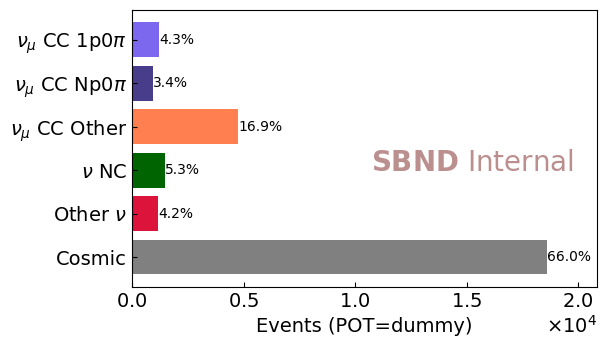

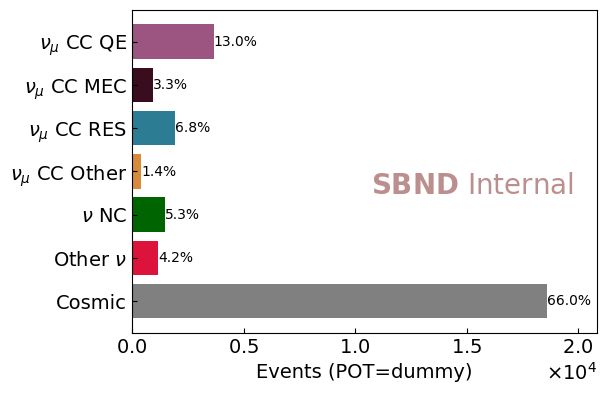

In [69]:
stage_key = "vertex_in_fv"

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_vertex_in_fv(df, det=DETECTOR)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

for d, d_dict in zip(
    (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df),
    (df_dict_mc, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_evt_df, intime_evt_df, dirt_evt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [71]:
# var_config = VariableConfig.nu_score()
# plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]

# for plot_type in ["topology"]: #, "genie"]:
#     save_name = save_fig_dir + "/selected-{}_{}.png".format(var_config.var_save_name, plot_type)
#     cov, frac_unc = get_frac_unc(mc_df, intime_df, offbeam_df, var_config)
#     ret_hist_topo = overlay_hists(plot_type,
#                                   mc_df=mc_df, 
#                                   data_df=data_df, 
#                                   intime_df=intime_df, 
#                                   dirt_df=dirt_df,
#                                   syst=cov,
#                                   ratio=True,
#                                   ax_ylim_ratio=1.7,
#                                   vline=[[NU_SCORE_TH, 1]],
#                                   var_config=var_config,
#                                   plot_labels=plot_labels,
#                                   save_fig=save_fig, 
#                                   save_name=save_name)

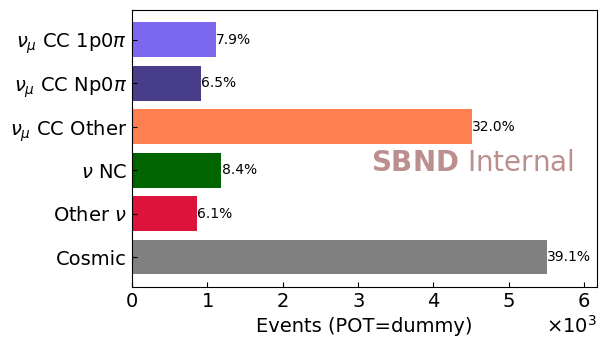

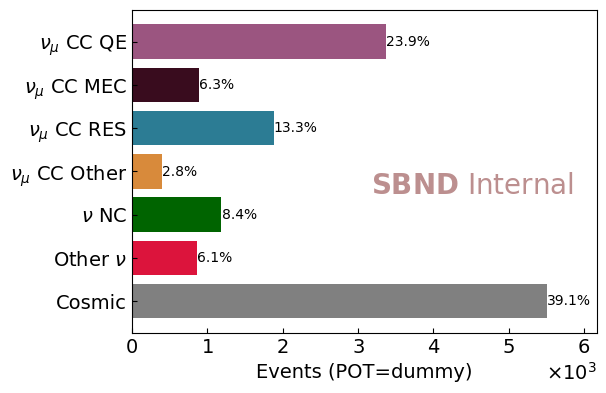

In [72]:
stage_key = "nu_score"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_nu_score(df, NU_SCORE_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

for d, d_dict in zip(
    (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df),
    (df_dict_mc, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

overlay_hists: could not load category_syst_summary ("Variable 'trk_dir_phi' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


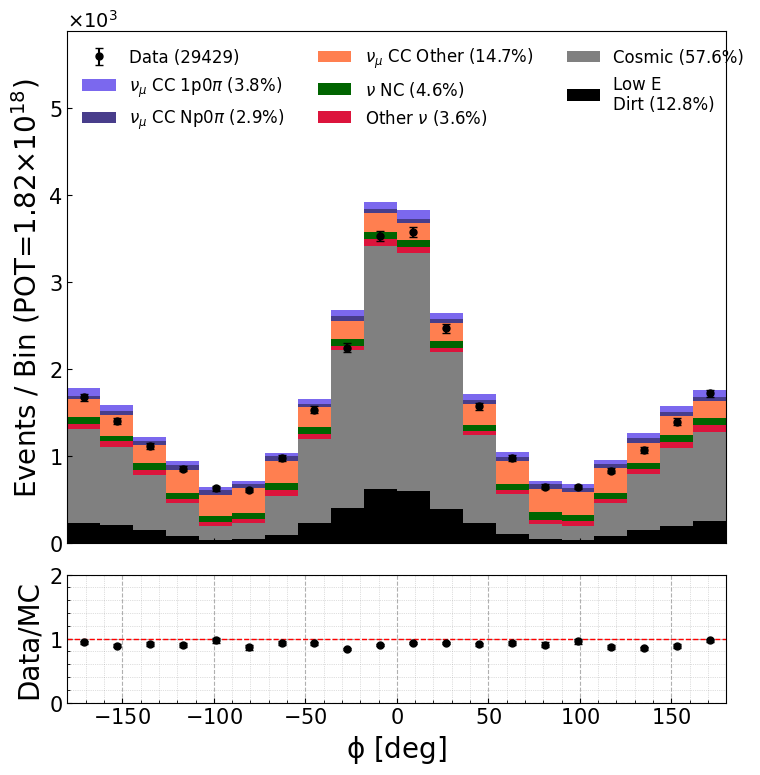

In [73]:
plot_type = "topology"
var_config = VariableConfig.prim_direction_phi()
plot_labels = [var_config.var_labels[0], "Events / Bin (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                        mc_df=mc_evt_df, 
                        data_df=data_evt_df, 
                        intime_df=intime_evt_df, 
                        dirt_df=dirt_evt_df,
                        # syst=get_frac_unc(mc_df, intime_df, offbeam_df, var_config)[1],
                        # syst_decomp = syst_decomp,
                        ratio=True,
                        # vline=[[50, 1]],
                        var_config=var_config,
                        plot_labels=plot_labels,
                        save_fig=save_fig, 
                        save_name=save_name)

## Slice has two tracks

In [74]:
# TODO: this is for det var samples
# TODO: move to dfmaker

chimu_avg = avg_chi2(mc_trk_df, "chi2_muon")
mc_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(mc_trk_df, "chi2_proton")
mc_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(data_trk_df, "chi2_muon")
data_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(data_trk_df, "chi2_proton")
data_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(intime_trk_df, "chi2_muon")
intime_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(intime_trk_df, "chi2_proton")
intime_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(offbeam_trk_df, "chi2_muon")
offbeam_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(offbeam_trk_df, "chi2_proton")
offbeam_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(dirt_trk_df, "chi2_muon")
dirt_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(dirt_trk_df, "chi2_proton")
dirt_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

In [79]:
mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    get_valid_trks(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)

mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    match_trkdf_to_slcdf(trk_df, df)
    for trk_df, df in ((mc_trk_df, mc_df), (data_trk_df, data_df), (intime_trk_df, intime_df), (offbeam_trk_df, offbeam_df), (dirt_trk_df, dirt_df))
)

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    get_trk_info(df, trk_df, SAVE_NTRKS)
    for df, trk_df in ((mc_evt_df, mc_trk_df), (data_evt_df, data_trk_df), (intime_evt_df, intime_trk_df), (offbeam_evt_df, offbeam_trk_df), (dirt_evt_df, dirt_trk_df))
)

overlay_hists: could not load category_syst_summary ("Variable 'n_trks' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


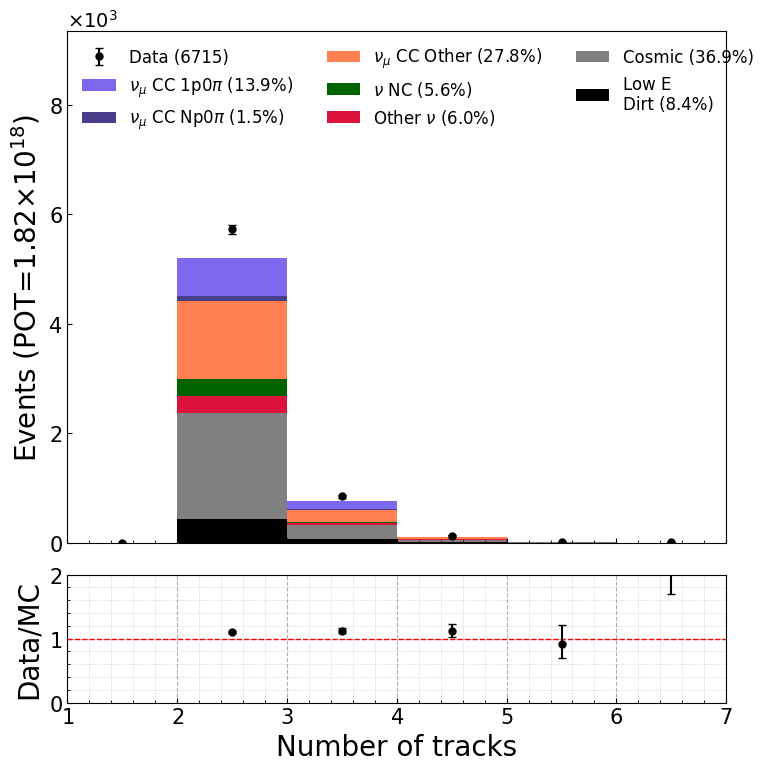

overlay_hists: could not load category_syst_summary ("Variable 'n_trks' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


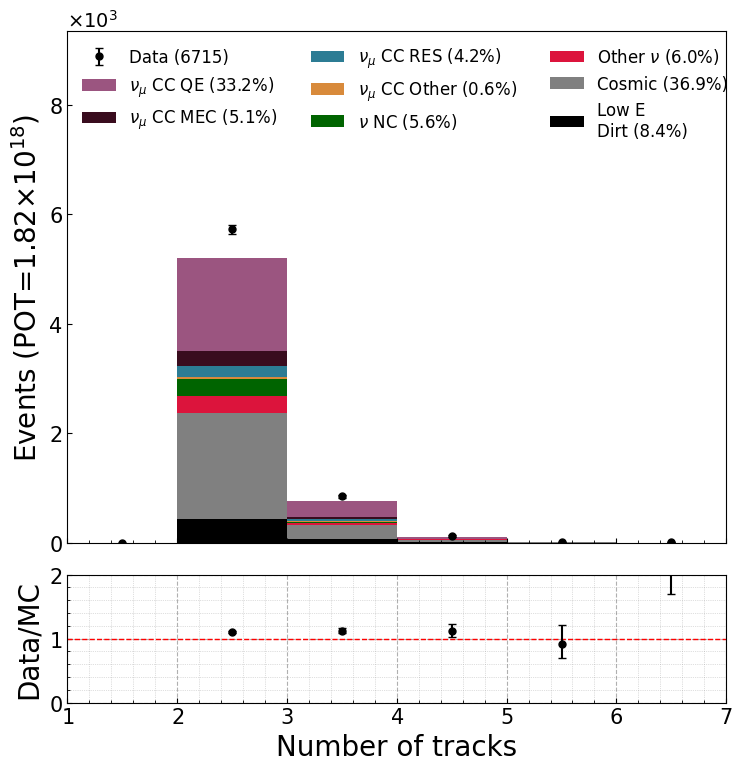

In [80]:
var_config = VariableConfig.n_trks()
plot_labels = ["Number of tracks", "Events (POT={})".format(pot_str), ""]

for plot_type in ["topology", "genie"]:
    save_name = save_fig_dir + "/selected-{}_{}.png".format("ntrks", plot_type)
    ret_hist_topo = overlay_hists(plot_type,
                                  mc_df=mc_df, 
                                  data_df=data_df, 
                                  intime_df=intime_df, 
                                  dirt_df=dirt_df,
                                  ratio=True,
                                  ax_ylim_ratio=1.8,
                                  var_config=var_config,
                                  plot_labels=plot_labels,
                                  save_fig=save_fig, 
                                  save_name=save_name)

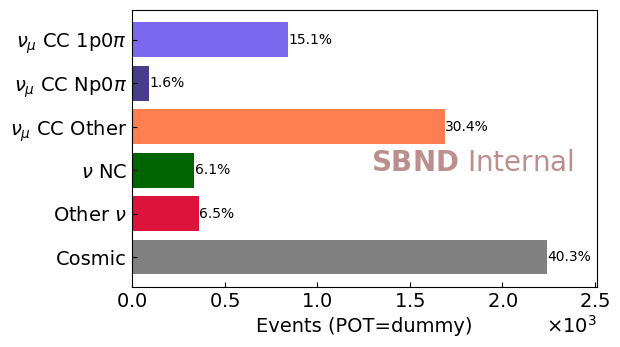

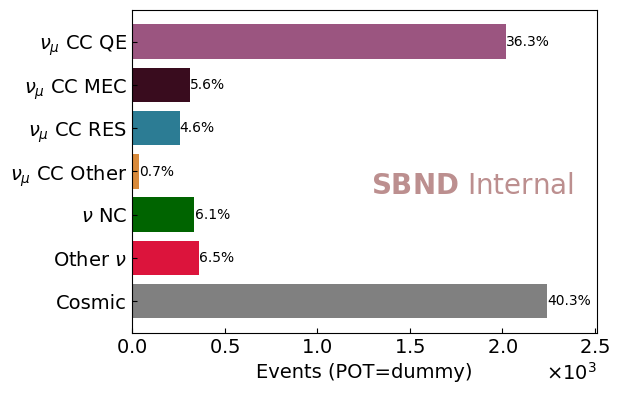

In [81]:
stage_key = "2prong"

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong(df)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

for d, d_dict in zip(
    (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df),
    (df_dict_mc, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_evt_df, intime_evt_df, dirt_evt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

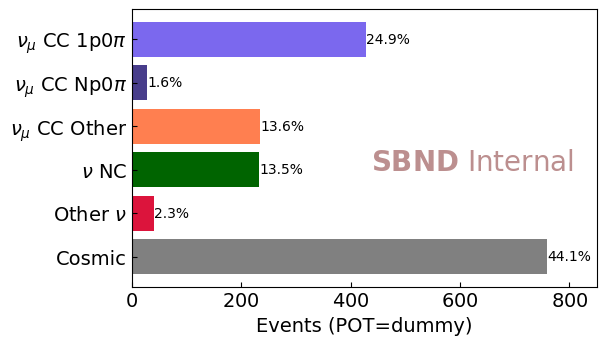

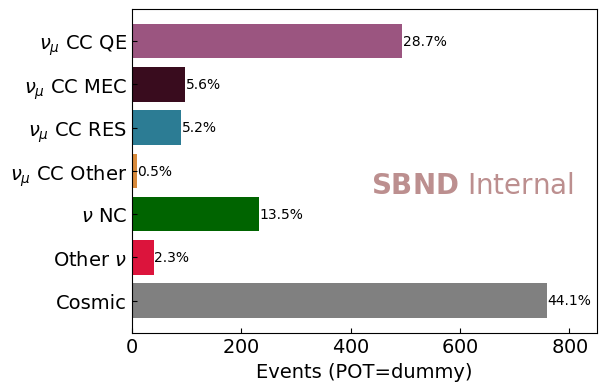

In [82]:
stage_key = "2prong-contained"

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_contained(df, det=DETECTOR)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

for d, d_dict in zip(
    (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df),
    (df_dict_mc, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_evt_df, intime_evt_df, dirt_evt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [83]:
mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    get_valid_trks(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)

mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    match_trkdf_to_slcdf(trk_df, df)
    for trk_df, df in ((mc_trk_df, mc_evt_df), (data_trk_df, data_evt_df), (intime_trk_df, intime_evt_df), (offbeam_trk_df, offbeam_evt_df), (dirt_trk_df, dirt_evt_df))
)

for trk_df, evt_df in [
    (mc_trk_df, mc_evt_df),
    (data_trk_df, data_evt_df),
    (intime_trk_df, intime_evt_df),
    (offbeam_trk_df, offbeam_evt_df),
    (dirt_trk_df, dirt_evt_df)
]:
    trk_df[('pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(
        trk_df['pfp', 'trk', 'dir', 'x', ''], 
        trk_df['pfp', 'trk', 'dir', 'y', '']
    ))

    prim_trk = trk_df.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
                        .groupby(level=[0,1,2]).head(1)\
                        .reset_index(level=[3]).pfp.trk.phi
    evt_df.loc[:, "prim_trk_phi"] = np.nan
    evt_df.loc[:, "prim_trk_phi"] = prim_trk

    prim_trk = trk_df.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
                        .groupby(level=[0,1,2]).head(1)\
                        .reset_index(level=[3]).pfp.trk.start.x
    evt_df.loc[:, "prim_trk_start_x"] = np.nan
    evt_df.loc[:, "prim_trk_start_x"] = prim_trk

    prim_trk = trk_df.sort_values(('pfp', 'trk', 'len', '', '', ''), ascending=False)\
                        .groupby(level=[0,1,2]).head(1)\
                        .reset_index(level=[3]).pfp.trk.end.x
    evt_df.loc[:, "prim_trk_end_x"] = np.nan
    evt_df.loc[:, "prim_trk_end_x"] = prim_trk

overlay_hists: could not load category_syst_summary ("Variable 'trk_dir_phi' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


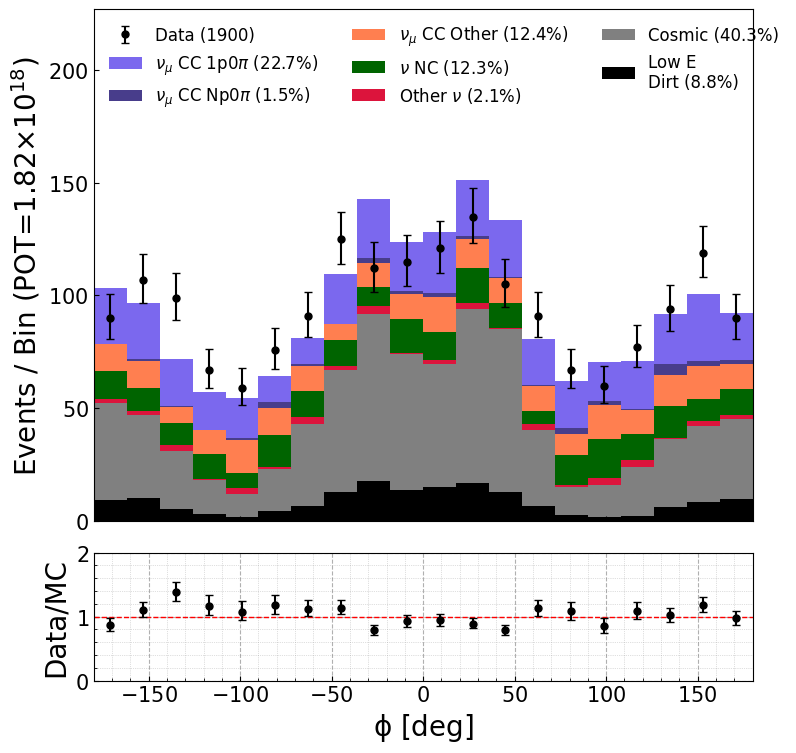

overlay_hists: could not load category_syst_summary ("Variable 'trk_start_x' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


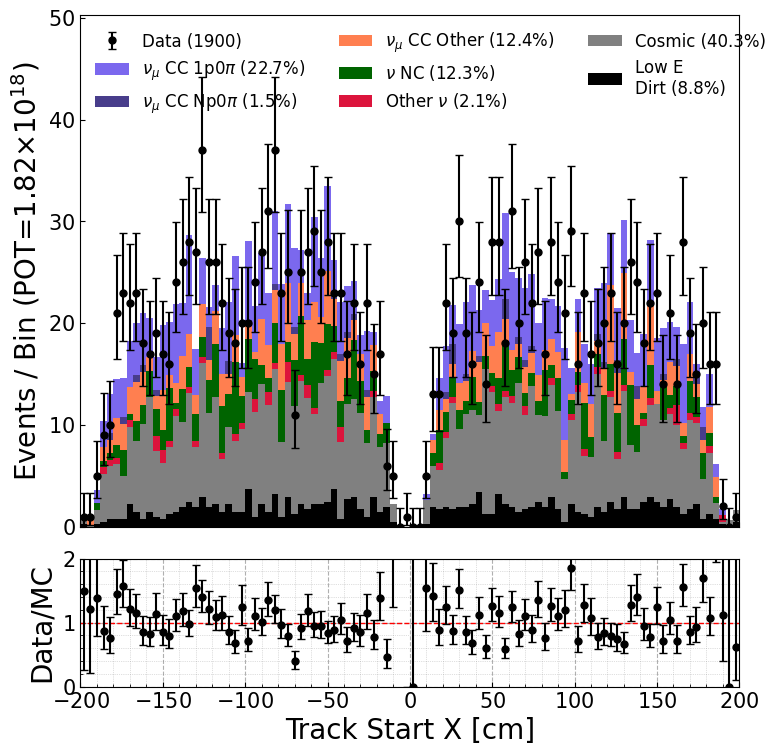

overlay_hists: could not load category_syst_summary ("Variable 'trk_end_x' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


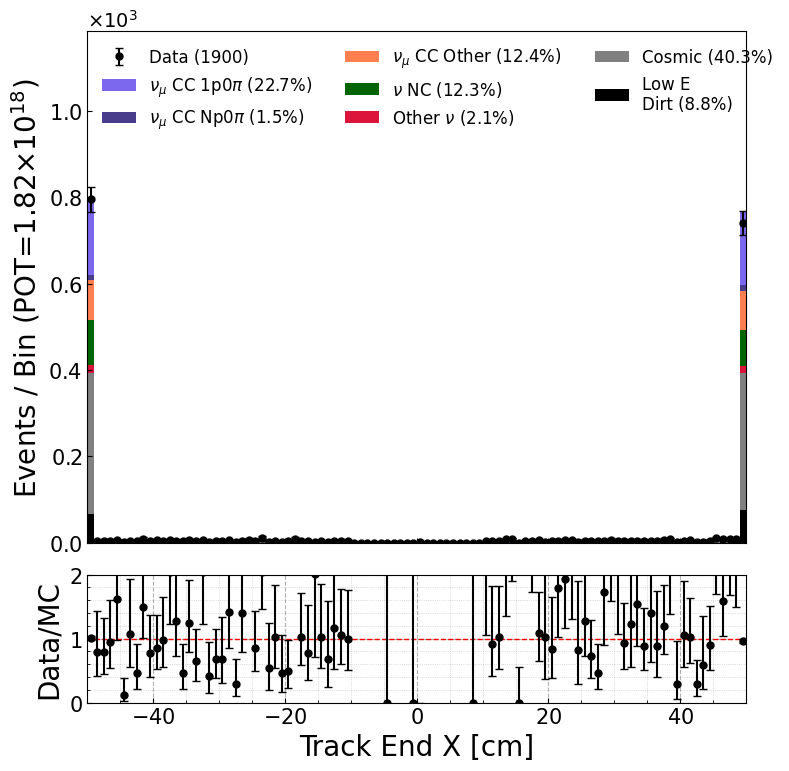

overlay_hists: could not load category_syst_summary ("Variable 'vertex_x' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


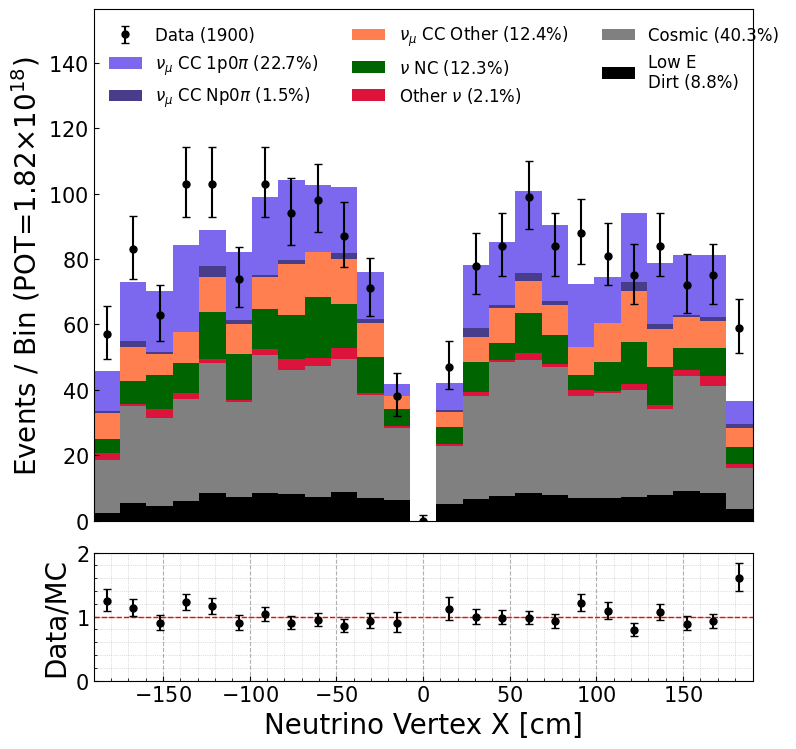

In [84]:
plot_type = "topology"
for var_config in [VariableConfig.prim_direction_phi(), VariableConfig.prim_start_x(), VariableConfig.prim_end_x(),
                    VariableConfig.vertex_x()]:
    plot_labels = [var_config.var_labels[0], "Events / Bin (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist = overlay_hists(plot_type,
                            mc_df=mc_evt_df, 
                            data_df=data_evt_df, 
                            intime_df=intime_evt_df, 
                            dirt_df=dirt_evt_df,
                            # syst=get_frac_unc(mc_df, intime_df, offbeam_df, var_config)[1],
                            # syst_decomp = syst_decomp,
                            ratio=True,
                            # vline=[[50, 1]],
                            var_config=var_config,
                            plot_labels=plot_labels,
                            save_fig=save_fig, 
                            save_name=save_name)

In [85]:
plot_type = "pdg"

mc_trk_df = pd.concat([mc_evt_df.trk1, mc_evt_df.trk2])
data_trk_df = pd.concat([data_evt_df.trk1, data_evt_df.trk2])
intime_trk_df = pd.concat([intime_evt_df.trk1, intime_evt_df.trk2])
offbeam_trk_df = pd.concat([offbeam_evt_df.trk1, offbeam_evt_df.trk2])
dirt_trk_df = pd.concat([dirt_evt_df.trk1, dirt_evt_df.trk2])

var_config = VariableConfig.track_score()

plot_labels = [var_config.var_labels[0], "Tracks / Bin (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                         mc_df=mc_trk_df, 
                         data_df=data_trk_df, 
                         intime_df=intime_trk_df, 
                         dirt_df=dirt_trk_df,
                        #  syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config)[1],
                        #  syst_decomp = False,
                         ratio=True,
                         ax_ylim_ratio=1.8,
                         vline=[[0.5, 1]],
                         var_config=var_config,
                         plot_labels=plot_labels,
                         save_fig=save_fig, 
                         save_name=save_name)

with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}.pkl', 'wb') as f:
    pickle.dump(ret_hist, f)

AttributeError: 'DataFrame' object has no attribute 'pot_weight'

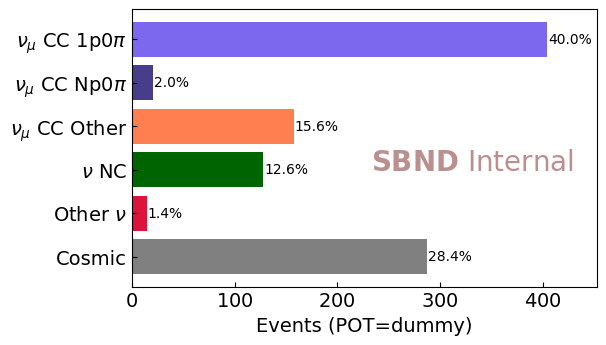

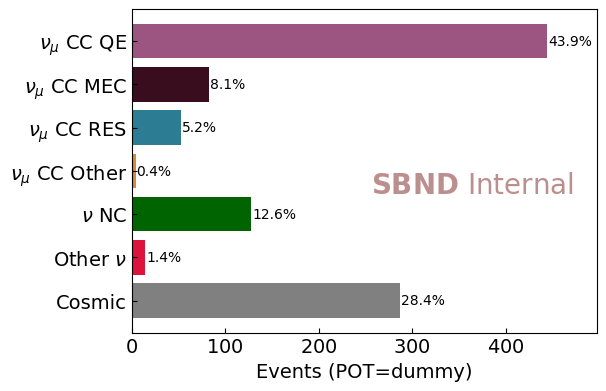

In [87]:
stage_key = "2prong-trackscore"

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

for d, d_dict in zip(
    (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df),
    (df_dict_mc, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_evt_df, intime_evt_df, dirt_evt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [88]:
plot_type = "pdg"
var_config = VariableConfig.trk_direction_phi()
plot_labels = [var_config.var_labels[0], "Events / Bin (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                        mc_df=mc_evt_df.trk2, 
                        data_df=data_evt_df.trk2, 
                        intime_df=intime_evt_df.trk2, 
                        dirt_df=dirt_evt_df.trk2,
                        # syst=get_frac_unc(mc_df, intime_df, offbeam_df, var_config)[1],
                        # syst_decomp = syst_decomp,
                        ratio=True,
                        # vline=[[50, 1]],
                        var_config=var_config,
                        plot_labels=plot_labels,
                        save_fig=save_fig, 
                        save_name=save_name)

AttributeError: 'DataFrame' object has no attribute 'pot_weight'

In [ ]:
plot_type = "pdg"

mc_trk_df = pd.concat([mc_evt_df.trk1, mc_evt_df.trk2])
data_trk_df = pd.concat([data_evt_df.trk1, data_evt_df.trk2])
intime_trk_df = pd.concat([intime_evt_df.trk1, intime_evt_df.trk2])
offbeam_trk_df = pd.concat([offbeam_evt_df.trk1, offbeam_evt_df.trk2])
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])

var_config = VariableConfig.vtx_dist()

plot_labels = [var_config.var_labels[0], "Tracks / Bin (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=intime_trk_df, 
                                dirt_df=dirt_trk_df,
                                # syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config)[1],
                                # syst_decomp = syst_decomp,
                                ratio=True,
                                vline=[[VTXDIST_TH, 0]],
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}.pkl', 'wb') as f:
    pickle.dump(ret_hist, f)

In [ ]:
plot_type = "pdg"
var_config = VariableConfig.trk_direction_phi()
plot_labels = [var_config.var_labels[0], "Events / Bin (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                        mc_df=mc_df.trk1, 
                        data_df=data_df.trk1, 
                        intime_df=intime_df.trk1, 
                        dirt_df=dirt_df.trk1,
                        # syst=get_frac_unc(mc_df, intime_df, offbeam_df, var_config)[1],
                        # syst_decomp = syst_decomp,
                        ratio=True,
                        # vline=[[50, 1]],
                        var_config=var_config,
                        plot_labels=plot_labels,
                        save_fig=save_fig, 
                        save_name=save_name)

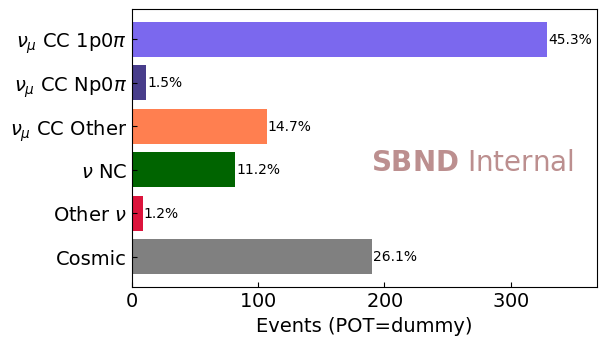

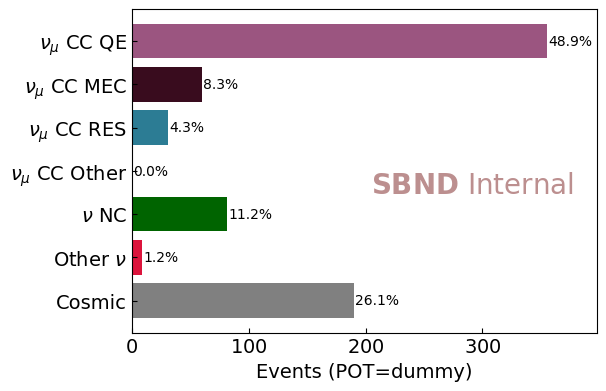

In [90]:
stage_key = "2prong-vtxdist"

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

for d, d_dict in zip(
    (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df),
    (df_dict_mc, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_evt_df, intime_evt_df, dirt_evt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [ ]:
plot_type = "pdg"
var_config = VariableConfig.trk_direction_phi()
plot_labels = [var_config.var_labels[0], "Events / Bin (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                        mc_df=mc_df.trk1, 
                        data_df=data_df.trk1, 
                        intime_df=intime_df.trk1, 
                        dirt_df=dirt_df.trk1,
                        # syst=get_frac_unc(mc_df, intime_df, offbeam_df, var_config)[1],
                        # syst_decomp = syst_decomp,
                        ratio=True,
                        # vline=[[50, 1]],
                        var_config=var_config,
                        plot_labels=plot_labels,
                        save_fig=save_fig, 
                        save_name=save_name)

## PID

In [ ]:
# compare using avg vs. single plane
plabels = ["Plane 0", "Plane 1", "Plane 2", "Average"]

var_config = VariableConfig.chi2_mu()
for ptag, plabel in zip(["I0", "I1", "I2", "avg"], plabels):
    var = mc_trk_df[("pfp", "trk", "chi2pid", ptag, "chi2_muon", "")]
    plt.hist(var, bins=var_config.bins, histtype="step", label=plabel, linewidth=2)

    plt.xlim(var_config.bins[0], var_config.bins[-1])
    plt.xlabel(var_config.var_labels[0])
    plt.ylabel("Tracks / Bin")
    plt.legend()
    plt.title("Tracks in 2-track Slices")

    # percentage of tracks with score = 0
    print(f"Percentage of tracks with score = 0: {np.sum((var == 0) | (var == np.nan)) / len(var)}")

if save_fig:
    plt.savefig(save_fig_dir + f"/{var_config.var_save_name}_plane_comparison.pdf", bbox_inches="tight")
    plt.show()

var_config = VariableConfig.chi2_proton()
for ptag, plabel in zip(["I0", "I1", "I2", "avg"], plabels):
    var = mc_trk_df[("pfp", "trk", "chi2pid", ptag, "chi2_proton", "")]
    plt.hist(var, bins=var_config.bins, histtype="step", label=plabel, linewidth=2)

    plt.xlim(var_config.bins[0], var_config.bins[-1])
    plt.xlabel(var_config.var_labels[0])
    plt.ylabel("Tracks / Bin")
    plt.legend()
    plt.title("Tracks in 2-track Slices")

if save_fig:
    plt.savefig(save_fig_dir + f"/{var_config.var_save_name}_plane_comparison.pdf", bbox_inches="tight")
    plt.show()

var_config = VariableConfig.chi2_proton()
for ptag, plabel in zip(["I0", "I1", "I2", "avg"], plabels):
    var = mc_trk_df[("pfp", "trk", "chi2pid", ptag, "chi2_proton", "")]
    bins = np.linspace(0, 10, 40)
    plt.hist(var, bins=bins, histtype="step", label=plabel, linewidth=2)
    plt.xlim(bins[0], bins[-1])
    plt.xlabel(var_config.var_labels[0])
    plt.ylabel("Tracks / Bin")
    plt.legend()
    plt.title("Tracks in 2-track Slices")

if save_fig:
    plt.savefig(save_fig_dir + f"/{var_config.var_save_name}_plane_comparison_zoom.pdf", bbox_inches="tight")
    plt.show()

In [ ]:
# does this make the behaviour more isotropic?
var1 = mc_trk_df[("pfp", "trk", "chi2pid", "I2", "chi2_muon", "")]
var_config = VariableConfig.chi2_mu()
bins1 = var_config.bins

var2 = mc_trk_df[("pfp", "trk", "dir", "z", "", "")]
bins2 = np.linspace(0, 1, 20)
plt.hist2d(var1, var2, bins=[bins1, bins2])
plt.colorbar(label="Tracks")
plt.xlabel("Proton $\\chi^2$")
plt.ylabel("X-Direction")
plt.show()

var1 = mc_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")]
var_config = VariableConfig.chi2_mu()
bins1 = var_config.bins

var2 = mc_trk_df[("pfp", "trk", "dir", "z", "", "")]
bins2 = np.linspace(0, 1, 20)
plt.hist2d(var1, var2, bins=[bins1, bins2])
plt.colorbar(label="Tracks")
plt.xlabel("Proton $\\chi^2$")
plt.ylabel("X-Direction")
plt.show()

In [ ]:
# all tracks in 2-track slices
plot_type = "pdg"
# plot_type = "topology"

mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])

for var_config in [VariableConfig.trk_len()]: 
                #    VariableConfig.chi2_mu(), 
                #    VariableConfig.chi2_proton()]:

    plot_labels = [var_config.var_labels[0], "Tracks / Bin (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist = overlay_hists(plot_type,
                                    mc_df=mc_trk_df, 
                                    data_df=data_trk_df, 
                                    intime_df=intime_trk_df, 
                                    dirt_df=dirt_trk_df,
                                    # syst=get_frac_unc(mc_trk_df, intime_trk_df, offbeam_trk_df, var_config)[1],
                                    # syst_decomp = syst_decomp,
                                    ratio=True,
                                    vline=[[50, 1]],
                                    var_config=var_config,
                                    plot_labels=plot_labels,
                                    save_fig=save_fig, 
                                    save_name=save_name)

    with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}.pkl', 'wb') as f:
        pickle.dump(ret_hist, f)

In [91]:
def get_mcs_range_diff(trks):
    mcs_range_diff = (trks.pfp.trk.rangeP.p_muon - trks.pfp.trk.mcsP.fwdP_muon) / trks.pfp.trk.rangeP.p_muon
    trks[("pfp", "trk", "mcs_range_diff", "", "", "")] = mcs_range_diff
    return trks

mc_trk_df = get_mcs_range_diff(mc_trk_df)
data_trk_df = get_mcs_range_diff(data_trk_df)
intime_trk_df = get_mcs_range_diff(intime_trk_df)
offbeam_trk_df = get_mcs_range_diff(offbeam_trk_df)
dirt_trk_df = get_mcs_range_diff(dirt_trk_df)

In [92]:
# tracks after len > 50 cm cut for muon selection
def len_cut(trks):
    trks = trks[trks.pfp.trk.len > 50]
    return trks

mc_trk_df = len_cut(mc_trk_df)
data_trk_df = len_cut(data_trk_df)
intime_trk_df = len_cut(intime_trk_df)
offbeam_trk_df = len_cut(offbeam_trk_df)
dirt_trk_df = len_cut(dirt_trk_df)

for var_config in [VariableConfig.mcs_range_diff()]: 

    plot_labels = [var_config.var_labels[0], "Tracks / Bin (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist_chi2mu = overlay_hists(plot_type,
                                    mc_df=mc_trk_df, 
                                    data_df=data_trk_df, 
                                    intime_df=intime_trk_df, 
                                    syst=None,  # no pre-saved systematics for track-level variables
                                    dirt_df=dirt_trk_df,
                                    ratio=True,
                                    vline=[[-QUAL_TH,0], [QUAL_TH,1]],
                                    var_config=var_config,
                                    plot_labels=plot_labels,
                                    save_fig=save_fig, 
                                    save_name=save_name)

    with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}-len50cm.pkl', 'wb') as f:
        pickle.dump(ret_hist, f)

AttributeError: 'DataFrame' object has no attribute 'pot_weight'

In [ ]:
# tracks after quality cut for muon selection
def mcs_range_diff_cut(trks):
    trks = trks[trks.pfp.trk.mcs_range_diff < QUAL_TH]
    return trks

# mc_trk_df = mcs_range_diff_cut(mc_trk_df) 
# data_trk_df = mcs_range_diff_cut(data_trk_df)
# intime_trk_df = mcs_range_diff_cut(intime_trk_df)
# dirt_trk_df = mcs_range_diff_cut(dirt_trk_df)
mc_trk_df_ = mc_trk_df.copy()
data_trk_df_ = data_trk_df.copy()
intime_trk_df_ = intime_trk_df.copy()
offbeam_trk_df_ = offbeam_trk_df.copy()
dirt_trk_df_ = dirt_trk_df.copy()

var_config = VariableConfig.chi2_mu()
plot_labels = [var_config.var_labels[0], "Tracks/ Bin  (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist_chi2mu = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=intime_trk_df, 
                                dirt_df=dirt_trk_df,
                                syst=None,  # no pre-saved systematics for track-level variables
                                ratio=True,
                                vline=[[MU_CHI2MU_TH, 0]],
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}-len50cm_qual{QUAL_TH}.pkl', 'wb') as f:
    pickle.dump(ret_hist, f)

var_config = VariableConfig.chi2_proton()
plot_labels = [var_config.var_labels[0], "Tracks / Bin (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
ret_hist_chi2mu = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=intime_trk_df, 
                                dirt_df=dirt_trk_df,
                                syst=None,  # no pre-saved systematics for track-level variables
                                ratio=True,
                                vline=[[MU_CHI2P_TH, 1]],
                                ax_ylim_ratio=1.8,
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}-len50cm_qual{QUAL_TH}.pkl', 'wb') as f:
    pickle.dump(ret_hist, f)

In [ ]:
save_fig_dir

In [ ]:
# get the percentage of tracks selected as mu

def get_mu_cut(trks):
    chimu_avg = trks.pfp.trk.chi2pid.avg.chi2_muon
    chip_avg = trks.pfp.trk.chi2pid.avg.chi2_proton
    mu_cut = (chimu_avg > 0) & (chimu_avg < MU_CHI2MU_TH) & (chip_avg > MU_CHI2P_TH) 
    return mu_cut

mc_mus = mc_trk_df[get_mu_cut(mc_trk_df)]
intime_mus = intime_trk_df[get_mu_cut(intime_trk_df)]
offbeam_mus = offbeam_trk_df[get_mu_cut(offbeam_trk_df)]
dirt_mus = dirt_trk_df[get_mu_cut(dirt_trk_df)]
data_mus = data_trk_df[get_mu_cut(data_trk_df)]

n_mc_mus = len(mc_mus.groupby(level=[0,1,2]).head(1))
n_intime_mus = len(intime_mus.groupby(level=[0,1,2]).head(1))
n_offbeam_mus = len(offbeam_mus.groupby(level=[0,1,2]).head(1))
n_dirt_mus = len(dirt_mus.groupby(level=[0,1,2]).head(1))
n_data_mus = len(data_mus.groupby(level=[0,1,2]).head(1))

print((n_mc_mus + n_intime_mus + n_dirt_mus) / (len(mc_trk_df) + len(intime_trk_df) + len(dirt_trk_df) + len(offbeam_trk_df)))
print(n_data_mus / len(data_trk_df))


In [ ]:
# compare chi2_mu vs. chi2_p 2D distributions and get the percentage out of total of the selected area
from matplotlib.colors import LogNorm

var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

plt.hist2d(mc_trk_df[var_config_1.var_evt_reco_col], 
           mc_trk_df[var_config_2.var_evt_reco_col], 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")

plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Internal    $\mathbf{SBND}$ Simulation", transform=plt.gca().transAxes, fontsize=14, color='rosybrown', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-MC.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

plt.hist2d(data_trk_df[var_config_1.var_evt_reco_col], 
           data_trk_df[var_config_2.var_evt_reco_col], 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")
plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Internal    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='rosybrown', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-data.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

In [ ]:
# tracks that aren't muon candidates
plot_type = "pdg"

def is_not_mu_candidate(trks):
    nlevels = len(mc_df.index.names)
    mcs_range_diff = np.abs((trks.pfp.trk.rangeP.p_muon - trks.pfp.trk.mcsP.fwdP_muon) / trks.pfp.trk.rangeP.p_muon)
    chimu_avg = trks.pfp.trk.chi2pid.avg.chi2_muon
    chip_avg = trks.pfp.trk.chi2pid.avg.chi2_proton
    mu_cut = (chimu_avg > 0) & (chimu_avg < MU_CHI2MU_TH) & \
            (chip_avg > MU_CHI2P_TH) & \
            (trks.pfp.trk.len > MU_LEN_TH) & \
            (mcs_range_diff < QUAL_TH)
    not_mu_candidate = pd.concat([trks[~mu_cut], trks[mu_cut].groupby(level=list(range(nlevels))).nth(1)])
    return not_mu_candidate

mc_trk_df = is_not_mu_candidate(mc_trk_df)
data_trk_df = is_not_mu_candidate(data_trk_df)
intime_trk_df = is_not_mu_candidate(intime_trk_df)
offbeam_trk_df = is_not_mu_candidate(offbeam_trk_df)
dirt_trk_df = is_not_mu_candidate(dirt_trk_df)

# vline_list = [P_CHI2MU_TH, P_CHI2P_TH]
# for vidx, var_config in enumerate([VariableConfig.chi2_mu(), VariableConfig.chi2_proton()]):
vline_list = [P_CHI2P_TH]
for vidx, var_config in enumerate([VariableConfig.chi2_proton()]):

    plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}.png".format(var_config.var_save_name, plot_type)
    ret_hist = overlay_hists(plot_type,
                                    mc_df=mc_trk_df, 
                                    data_df=data_trk_df, 
                                    intime_df=intime_trk_df, 
                                    dirt_df=dirt_trk_df,
                                    syst=None,  # no pre-saved systematics for track-level variables
                                    ratio=True,
                                    vline=[vline_list[vidx]],
                                    var_config=var_config,
                                    plot_labels=plot_labels,
                                    save_fig=save_fig, 
                                    save_name=save_name)

    with open(f'{save_nevts_dir}/{syst_tag}_{var_config.var_save_name}-not_mu_candidate.pkl', 'wb') as f:
        pickle.dump(ret_hist, f)

In [ ]:
var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

plt.hist2d(mc_trk_df[var_config_1.var_evt_reco_col], 
           mc_trk_df[var_config_2.var_evt_reco_col], 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.axhline(P_CHI2P_TH, color="red", linestyle="--")

plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Internal    $\mathbf{SBND}$ Simulation", transform=plt.gca().transAxes, fontsize=14, color='rosybrown', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-not_mu_candidate-MC.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

plt.hist2d(data_trk_df[var_config_1.var_evt_reco_col], 
           data_trk_df[var_config_2.var_evt_reco_col], 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.axhline(P_CHI2P_TH, color="red", linestyle="--")

plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Internal    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='rosybrown', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-not_mu_candidate-data.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

In [ ]:
mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    get_mu_p_candidate(df, 
                       mu_chi2mu_th=MU_CHI2MU_TH, mu_chi2p_th=MU_CHI2P_TH, mu_len_th=MU_LEN_TH, qual_th=QUAL_TH,
                       p_chi2mu_th=-1, p_chi2p_th=P_CHI2P_TH, p_len_th=P_LEN_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

In [ ]:
stage_key = "2prong-muX"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_has_mu(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)
mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_mu_kinematics(df, mu_Plo_th=MU_PLO_TH, mu_Phi_th=MU_PHI_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [ ]:
stage_key = "2prong-mup"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_has_p(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)
mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_p_kinematics(df, p_Plo_th=P_PLO_TH, p_Phi_th=P_PHI_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [ ]:
# per-TPC containment (same logic as the 2prong-contained stage)
perTPC_cut = event_contained_per_tpc(mc_df)
print("precut", len(mc_df))
print("postcut", len(mc_df[perTPC_cut]))
print("eff", len(mc_df[perTPC_cut]) / len(mc_df))

In [ ]:
for k in df_dict_data.keys():
    print(k, len(df_dict_data[k]))

## Calculated derived variables

- now that we've identified mu and p candidates, calculate opening angle, TKI, ...

In [ ]:
sel_dfs = {
    "mc_df": mc_df,
    "data_df": data_df,
    "intime_df": intime_df,
    "dirt_df": dirt_df
}

with open(f'{save_nevts_dir}/{syst_tag}_sel_mup.pkl', 'wb') as f:
    pickle.dump(sel_dfs, f)


In [ ]:
save_nevts_dir

# Event Selection Summary Breakdown Plot

In [ ]:
print(df_dict.keys())
stage_labels = [
    "All reconstructed slices",
    "Not clear cosmic",
    "Vertex in Gen-1 fiducial volume",
    "Nu-score > {}".format(NU_SCORE_TH),
    "Has exactly 2 PFPs",
    "Both PFPs per-TPC contained",
    "Both PFPs have track score > {}".format(TRACKSCORE_TH),
    "Both track \n(start position - vertex) < {} cm".format(VTXDIST_TH),
    "One track is muon-like",
    "The other is proton-like"
]

In [ ]:
stages = list(breakdown_dict["topology"].keys())[::-1]
y = np.arange(len(stages))
bar_width = 0.3

def stack_bars(ax, data, yoffset, colors, label):
    left = np.zeros(len(stages))
    bars = []
    for i, color in enumerate(colors[:data.shape[1]]):
        b = ax.barh(y + yoffset, data[:, i], bar_width, left=left, color=color, label=label if i == 0 else None)
        bars.append(b)
        left += data[:, i]
    return bars

topo_data = np.array([breakdown_dict["topology"][stage] for stage in stages])[:, ::-1]
genie_data = np.array([breakdown_dict["genie"][stage] for stage in stages])[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 10))
stack_bars(ax, topo_data, -bar_width/2, topology_colors, "Topology")
stack_bars(ax, genie_data,  bar_width/2,  genie_mode_colors, "GENIE")

ax.set_xlabel("Percentage (%)")
ax.set_yticks(y)
ax.set_yticklabels(stage_labels[::-1], fontsize=12)

common_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["gray", "sienna", "crimson", "darkgreen"],
    ["Cosmic", r"Out FV $\nu$", r"In FV other $\nu$", r"In FV $\nu_{\mu}$ NC"]
)]
genie_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["#BFB17C", "#D88A3B", "#2c7c94", "#390C1E", "#9b5580"],
    [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC SIS/DIS", r"In FV $\nu_{\mu}$ CC RES", r"In FV $\nu_{\mu}$ CC MEC", r"In FV $\nu_{\mu}$ CC QE"]
)]
topo_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["coral", "darkslateblue", "mediumslateblue"],
    [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC Np0$\pi$", r"In FV $\nu_{\mu}$ CC 1p0$\pi$"]
)]

ax.legend(handles=common_patches, loc='upper left', bbox_to_anchor=(0.01,1.18), ncol=4, fontsize=12, frameon=False)
for i, handles in enumerate([genie_patches[::-1], topo_patches[::-1]]):
    ax_i = ax.twinx()
    ax_i.legend(handles=handles, loc='upper left', 
                bbox_to_anchor=(0.01, 1.14 - 0.07*i), # space out
                ncol=3 if i==0 else 4, fontsize=12, frameon=False)
    ax_i.set_yticks([])

if save_fig:
    plt.savefig(f"{save_fig_dir}/event_selection_summary.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [ ]:
eps = 1e-8
ratio = True
approval = ""
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

ret = overlay_hists(breakdown_type=breakdown_type,
                    var_config=VariableConfig.muon_momentum(),
                    mc_df=mc_df,
                    data_df=data_df,
                    intime_df=intime_df,
                    dirt_df=dirt_df,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    textloc=textloc,
                    approval=approval,
                    plot_labels=plot_labels_hist,
                    syst=None,
                    save_fig=False, 
                    save_name=None)

# Efficiency Curves

In [ ]:
eff_dict = {}
for var_config in [VariableConfig.muon_momentum(), VariableConfig.muon_direction(),
                   VariableConfig.proton_momentum(), VariableConfig.proton_direction()]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval=approval, 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
for var_config in [VariableConfig.muon_direction_x(), VariableConfig.muon_direction_y(),
                   VariableConfig.proton_direction_x(), VariableConfig.proton_direction_y()]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval=approval, 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
for var_config in [ VariableConfig.vertex_x(), VariableConfig.vertex_y(), VariableConfig.vertex_z()]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval=approval, 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
for var_config in [ VariableConfig.opening_angle(),
                   VariableConfig.tki_del_Tp(), VariableConfig.tki_del_p(), VariableConfig.tki_del_Tp_x(), VariableConfig.tki_del_Tp_y(),
                   VariableConfig.tki_del_alpha(), VariableConfig.tki_del_phi(),]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval=approval, 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
var_config = VariableConfig.neutrino_energy()
save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
ret = plot_efficiency(df_dict,
                stage_labels,
                var_config, 
                textloc=[0.05, 1.08],
                approval=approval, 
                legend=True,
                save_fig=save_fig, 
                save_name=save_name)

eff_dict[var_config.var_save_name] = ret

In [ ]:
with open(f'{save_fig_dir}/{syst_tag}_eff_dict.pkl', 'wb') as f:
    pickle.dump(eff_dict, f)

In [ ]:
save_fig_dir